# 3-Pulse Mach-Zehnder Interferometer with Temperature — New Pulse API

Replicates `mach_zehnder_with_temperature.ipynb` using the new event-based pulse sequence API
(`build_mach_zehnder_pulse_sequence` + `calculate_excited_fraction_for_pulse_sequence`).

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.

Repeat with detunings drawn from a distribution based on a Maxwell-Boltzmann distribution of velocities at $T = 200\,\mathrm{nK}$.

A final comparison cell verifies numerical equivalence with the old low-level implementation.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

import version_info as vs

from lmt_sim.lmt_sequence import (
    build_mach_zehnder_pulse_sequence,
    calculate_excited_fraction_for_pulse_sequence,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
)

%matplotlib inline

In [3]:
# np.random.seed(42)

T_FREE = 200e-6  # Free evolution time between pulses

MASS_ATOM = constants.atomic_mass * 87

# Draw velocities from 1D Maxwell-Boltzmann distribution at T
# 1D MB is a Gaussian with sigma_v = sqrt(k_B T / m)
N_ATOMS = 200
TEMPERATURE = 200e-9

sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0, sigma_v, size=N_ATOMS)
phi_values = np.linspace(0, 2 * np.pi, 101)

In [4]:
from tqdm import tqdm


def calc_mz_excitation_pulse_api(
    phi,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    pulse_sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=time_between_pulses,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    return calculate_excited_fraction_for_pulse_sequence(
        pulse_sequence,
        velocity=(0.0, 0.0, initial_velocity_z),
    )


# Simulate for each atom velocity
excitation_curves = np.empty((N_ATOMS, len(phi_values)))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    excitation_fractions = np.empty_like(phi_values)

    for ind_phi, phi in enumerate(phi_values):
        excitation_fractions[ind_phi] = calc_mz_excitation_pulse_api(
            phi,
            initial_velocity_z=velocity,
            time_between_pulses=T_FREE,
        )

        if excitation_fractions[ind_phi] < 0 or excitation_fractions[ind_phi] > 1:
            print(
                f"Warning: Unphysical excitation fraction {excitation_fractions[ind_phi]:.3f} "
                f"for velocity {velocity:.2f} m/s, phi={phi:.2f}"
            )

    excitation_curves[ind_atom, :] = excitation_fractions

mean_excitation = np.mean(excitation_curves, axis=0)
std_excitation = np.std(excitation_curves, axis=0)


Simulating atoms:   0%|          | 0/200 [00:00<?, ?it/s]


Simulating atoms:   1%|          | 2/200 [00:00<00:17, 11.48it/s]


Simulating atoms:   2%|▏         | 4/200 [00:00<00:18, 10.47it/s]


Simulating atoms:   3%|▎         | 6/200 [00:00<00:18, 10.26it/s]


Simulating atoms:   4%|▍         | 8/200 [00:00<00:18, 10.49it/s]

...


Simulating atoms:  97%|█████████▋| 194/200 [00:17<00:00, 10.44it/s]


Simulating atoms:  98%|█████████▊| 196/200 [00:17<00:00, 10.47it/s]


Simulating atoms:  99%|█████████▉| 198/200 [00:18<00:00, 10.73it/s]


Simulating atoms: 100%|██████████| 200/200 [00:18<00:00, 10.70it/s]


Simulating atoms: 100%|██████████| 200/200 [00:18<00:00, 10.97it/s]

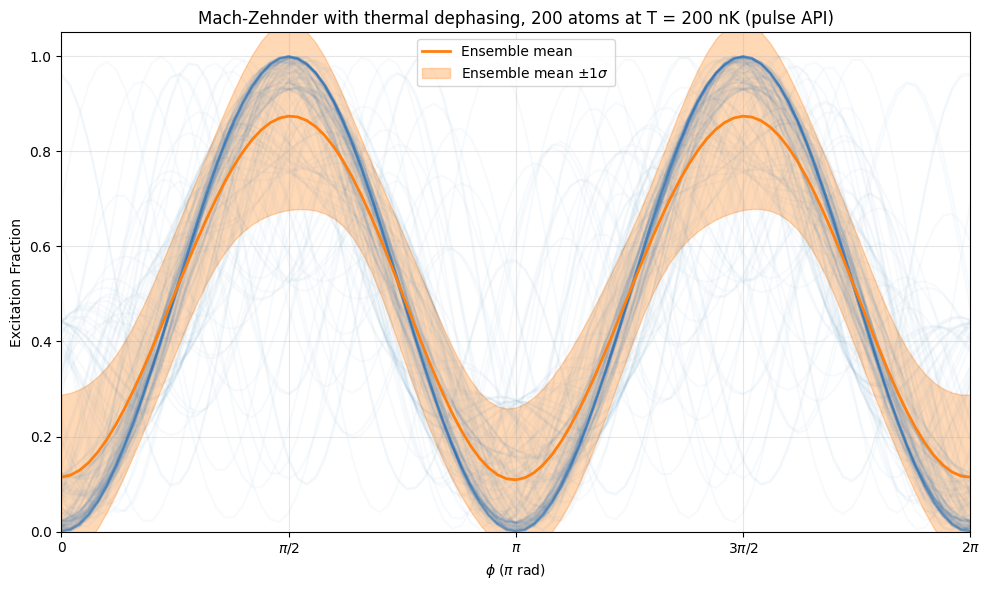

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual traces with low alpha
for curve in excitation_curves:
    ax.plot(phi_values / np.pi, curve, color="tab:blue", alpha=0.03)

# Plot mean and std
ax.plot(
    phi_values / np.pi,
    mean_excitation,
    color="tab:orange",
    lw=2,
    label="Ensemble mean",
)
ax.fill_between(
    phi_values / np.pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.3,
    label=r"Ensemble mean $\pm 1\sigma$",
)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title(
    f"Mach-Zehnder with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE*1e9:.0f} nK (pulse API)"
)
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()

## Ensemble mean comparison

Run the same fixed-seed velocity ensemble through both the old low-level API and the new
pulse-sequence API and compare the resulting ensemble mean curves.
This is the meaningful test: any systematic difference between the two implementations
would survive the average and show up as a non-zero residual.

# Visualisations


## Simulated camera images

These synthetic camera images use the new event-based pulse-sequence API so each atom contributes weighted output branches with explicit final positions. The ground-state camera is read out immediately at the end of the sequence, while the excited-state camera is imaged after one additional 4 ms freefall.

The camera is displayed with $z$ vertical and $x$ horizontal. In this notebook the atoms start on-axis with no transverse velocity, so the horizontal extent is dominated by the single-atom wave-packet blur rather than real transverse cloud expansion.

**Imaging model (heuristic — see `lmt_sim.imaging` module docstring).** Within a single atom, branches that fall in the same camera pixel are summed *coherently* (so interferometer fringes survive), while different atoms in the thermal ensemble add *incoherently*. Each image is then blurred by a Gaussian standing in for the finite single-atom wave-packet size after expansion (`SINGLE_ATOM_WAVEPACKET_SIGMA_M ≈ 10 µm`). This "same pixel ⇒ interferes" rule is a placeholder; the correct treatment is proper Gaussian wave-packet tracking, which is the entire purpose of the per-branch position/velocity bookkeeping. **TODO: implement wave-packet tracking** (deliberately deferred).

The image color scale shows **density per pixel**, not total atom number. Because the excited-state image is taken after an extra 4 ms freefall, that cloud is more spread out, so it can look dimmer or broader even when it contains more atoms overall. To compare with the excitation-fraction curve, use the integrated ground and excited weights printed by the code cell below.

The blur width (`blur_sigma_m`), imaging phase, delay, and z/x bin counts are the main knobs to retune in the code cell below.



Rendering camera shot:   0%|          | 0/200 [00:00<?, ?it/s]


Rendering camera shot:  48%|████▊     | 95/200 [00:00<00:00, 948.21it/s]


Rendering camera shot:  95%|█████████▌| 190/200 [00:00<00:00, 829.42it/s]


Rendering camera shot: 100%|██████████| 200/200 [00:00<00:00, 851.14it/s]

Camera phase:                     1.10pi rad
Camera-inferred excited fraction: 0.1908
Ensemble mean at nearest phase:   0.1900


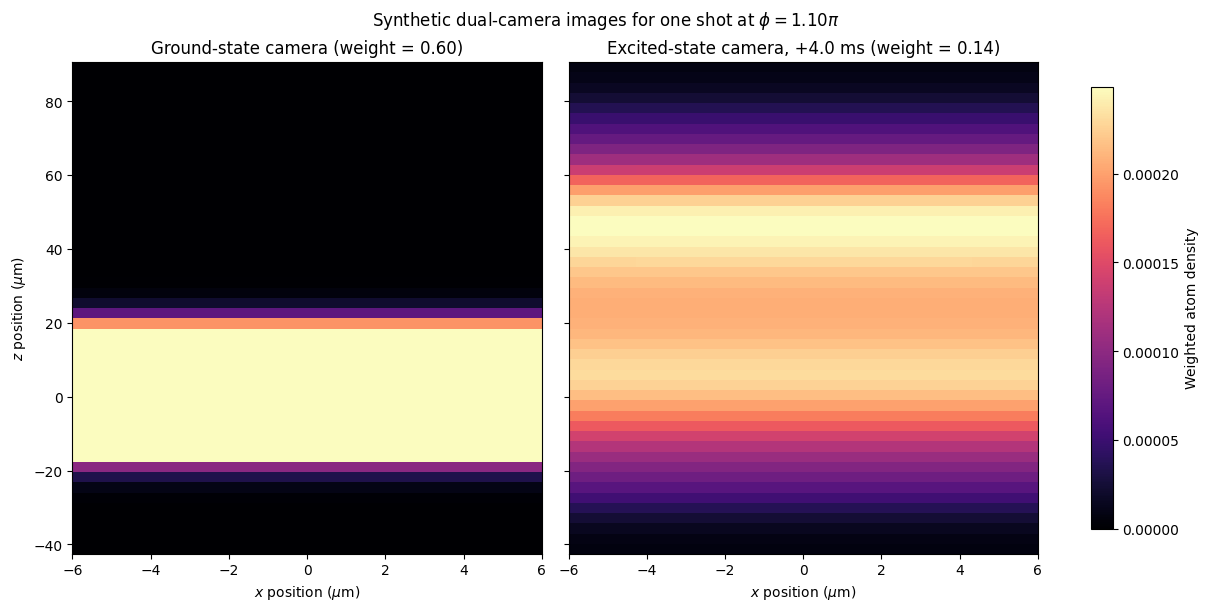

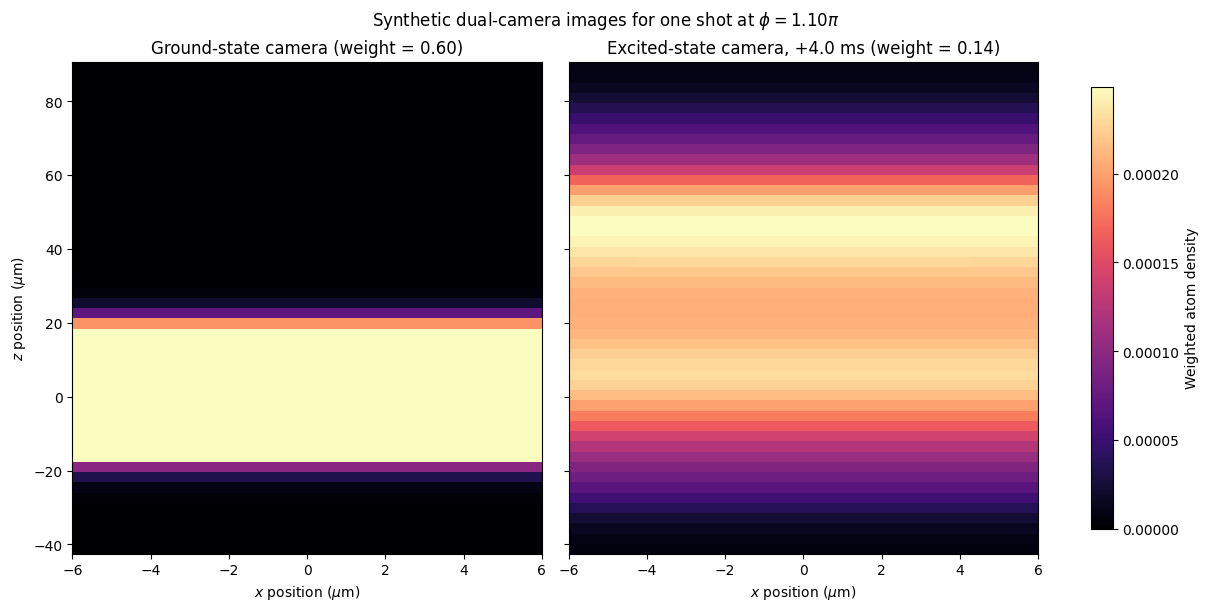

In [6]:
import numpy as np
from tqdm import tqdm

from lmt_sim.lmt_sequence import (
    build_mach_zehnder_pulse_sequence,
    run_pulse_sequence_in_lab_frame,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
    make_atom_states,
)
from lmt_sim.imaging import collect_branches, plot_camera_shot, pixel_grid, render, stack_atoms

CAMERA_PHASE = 1.1 * np.pi
CAMERA_EXCITED_DELAY = 4e-3  # excited camera reads out this long after the ground one

# Collect the ensemble's ground and excited branches. The excited camera is read
# CAMERA_EXCITED_DELAY after the ground readout, so excited z advances
# ballistically by v_z * delay. Each velocity class is a distinct atom, so we
# stack with per-atom ids: render() sums each atom's branches coherently (as
# wave packets) but keeps different atoms incoherent.
ground, excited = [], []
for v in tqdm(velocities, desc="Rendering camera shot"):
    sequence = build_mach_zehnder_pulse_sequence(
        phi=CAMERA_PHASE,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=T_FREE,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    state, _, _ = run_pulse_sequence_in_lab_frame(
        make_atom_states(initial_velocity_z=v, c0=1, c1=0),
        sequence,
        initial_velocity_z=v,
    )
    g, e = collect_branches(state)
    if len(e):
        e[:, 1] += e[:, 2] * CAMERA_EXCITED_DELAY
    ground.append(g)
    excited.append(e)

ground = stack_atoms(ground)
excited = stack_atoms(excited)

# Imaged weight = integrated camera intensity (per-atom coherent wave-packet
# sum, atoms incoherent), on the same grid plot_camera_shot uses. The absolute
# value is in imaged-intensity units; the meaningful quantity is the fraction.
_x_edges, _z_edges = pixel_grid([ground, excited], n_x=21, n_z=48,
                                x_pad_frac=0.25, z_pad_frac=0.15)
ground_total = render(ground, _x_edges, _z_edges).sum()
excited_total = render(excited, _x_edges, _z_edges).sum()
camera_excited_fraction = excited_total / (ground_total + excited_total)
ensemble_excited_fraction = mean_excitation[np.argmin(np.abs(phi_values - CAMERA_PHASE))]

print(f"Camera phase:                     {CAMERA_PHASE / np.pi:.2f}pi rad")
print(f"Camera-inferred excited fraction: {camera_excited_fraction:.4f}")
print(f"Ensemble mean at nearest phase:   {ensemble_excited_fraction:.4f}")

plot_camera_shot(
    ground, excited,
    ground_title=f"Ground-state camera (weight = {ground_total:.2f})",
    excited_title=f"Excited-state camera, +{1e3 * CAMERA_EXCITED_DELAY:.1f} ms (weight = {excited_total:.2f})",
    suptitle=f"Synthetic dual-camera images for one shot at $\\phi = {CAMERA_PHASE / np.pi:.2f}\\pi$",
)


## Filmstrip through the sequence

Same camera, but stepping through the sequence event by event. After each prefix `sequence[:i]` we re-image both the ground and excited cameras, so the panel shows how the wave packet splits and spreads through the three pulses. Each panel autoscales to its own peak; `w=` / `peak=` annotations make brightness comparable across panels.

`plot_mz_filmstrip(phi)` runs the whole thing for a chosen pulse phase; the cells below sweep it across a fringe.

In [7]:
from lmt_sim.imaging import plot_filmstrip


def plot_mz_filmstrip(phi):
    sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=T_FREE,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    return plot_filmstrip(
        sequence, velocities,
        title=f"MZ filmstrip at $\\phi = {phi / np.pi:.3f}\\pi$ (each panel autoscaled)",
        desc=f"phi={phi / np.pi:.3f}pi",
    )


phi=0.000pi:   0%|          | 0/200 [00:00<?, ?it/s]


phi=0.000pi:  36%|███▌      | 72/200 [00:00<00:00, 719.12it/s]


phi=0.000pi:  72%|███████▏  | 144/200 [00:00<00:00, 719.37it/s]


phi=0.000pi: 100%|██████████| 200/200 [00:00<00:00, 720.76it/s]

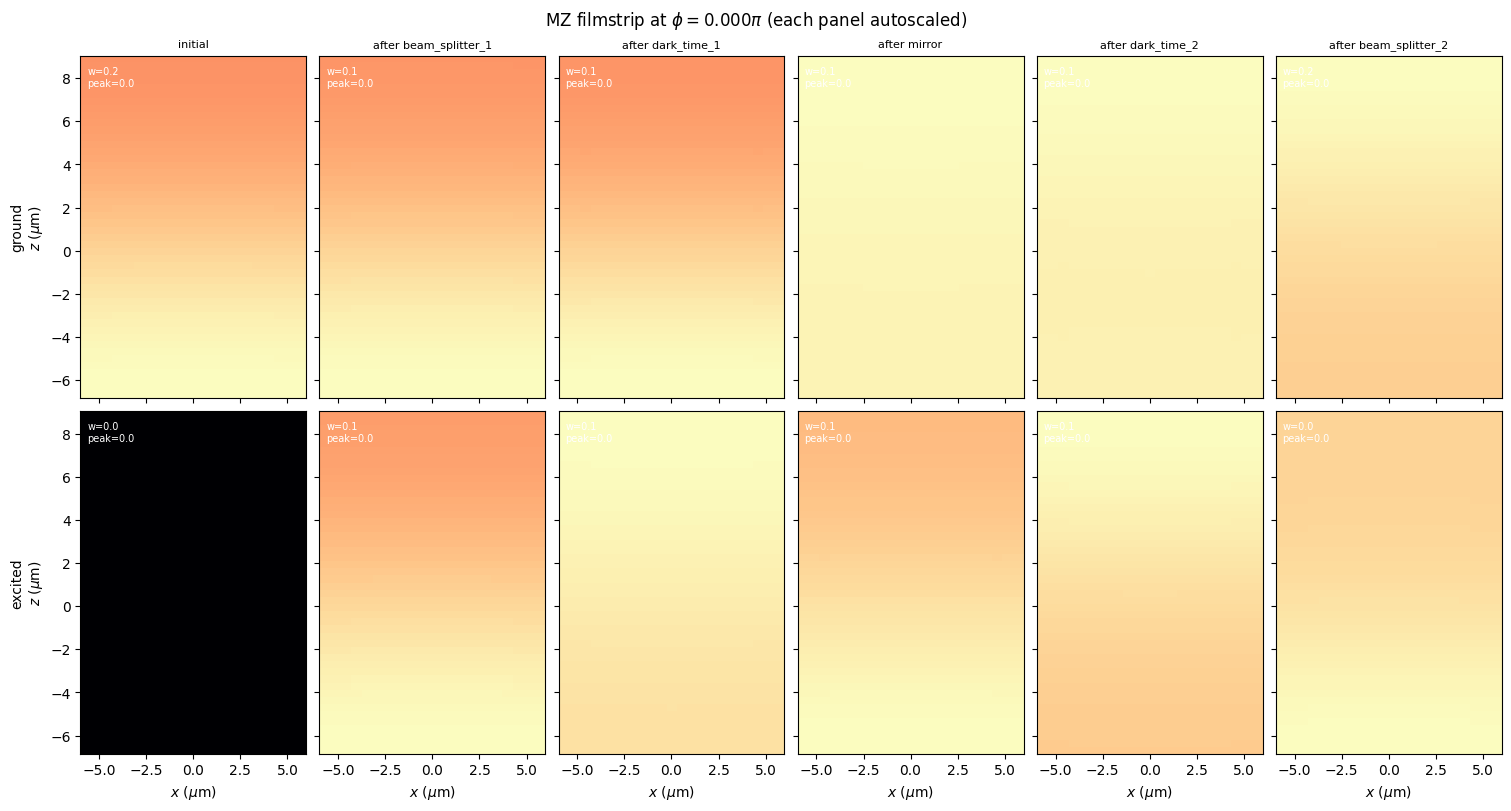

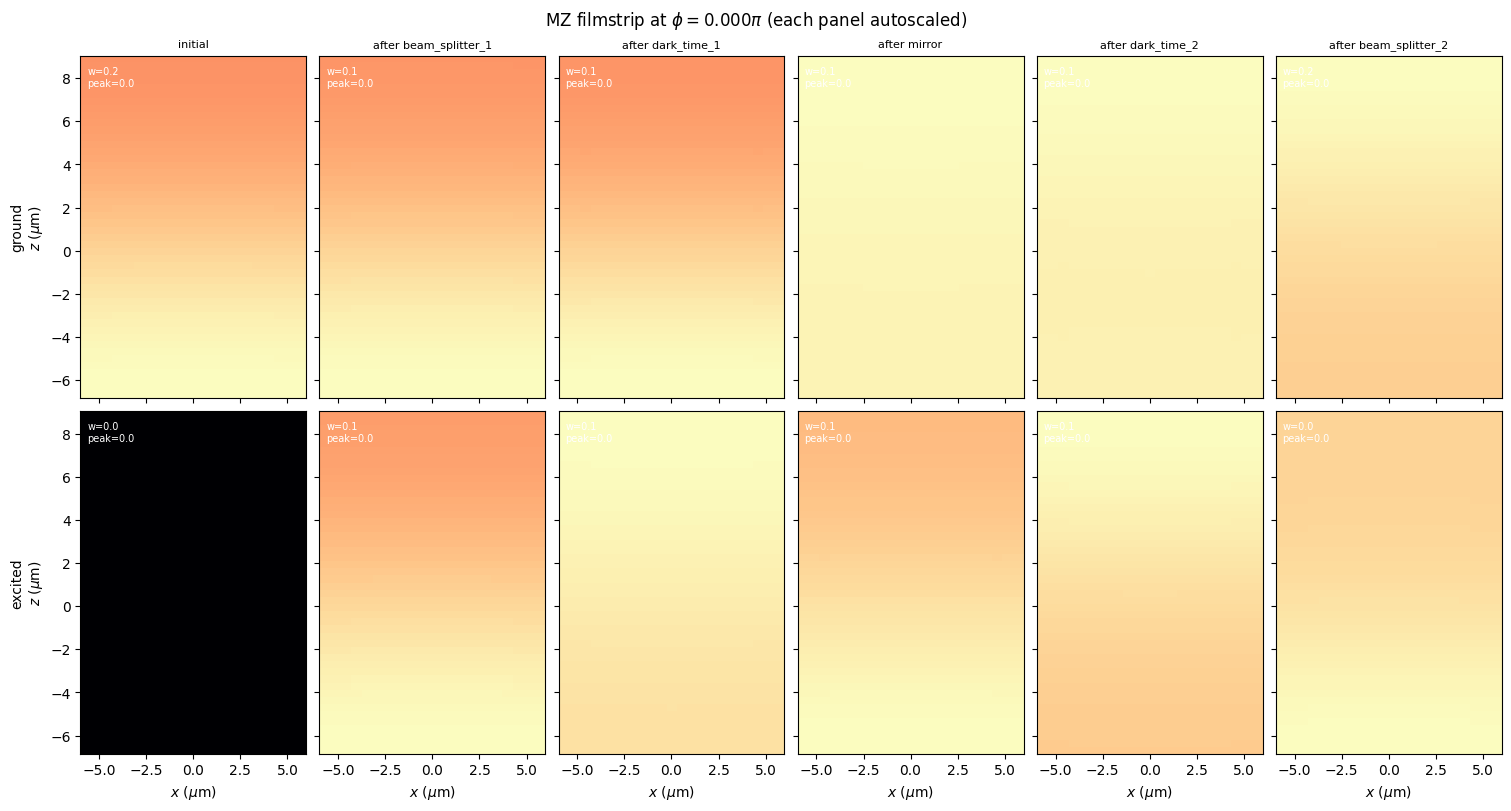

In [8]:
plot_mz_filmstrip(0.0)


phi=0.500pi:   0%|          | 0/200 [00:00<?, ?it/s]


phi=0.500pi:  32%|███▏      | 64/200 [00:00<00:00, 631.02it/s]


phi=0.500pi:  64%|██████▍   | 129/200 [00:00<00:00, 636.06it/s]


phi=0.500pi:  96%|█████████▋| 193/200 [00:00<00:00, 625.97it/s]


phi=0.500pi: 100%|██████████| 200/200 [00:00<00:00, 624.91it/s]

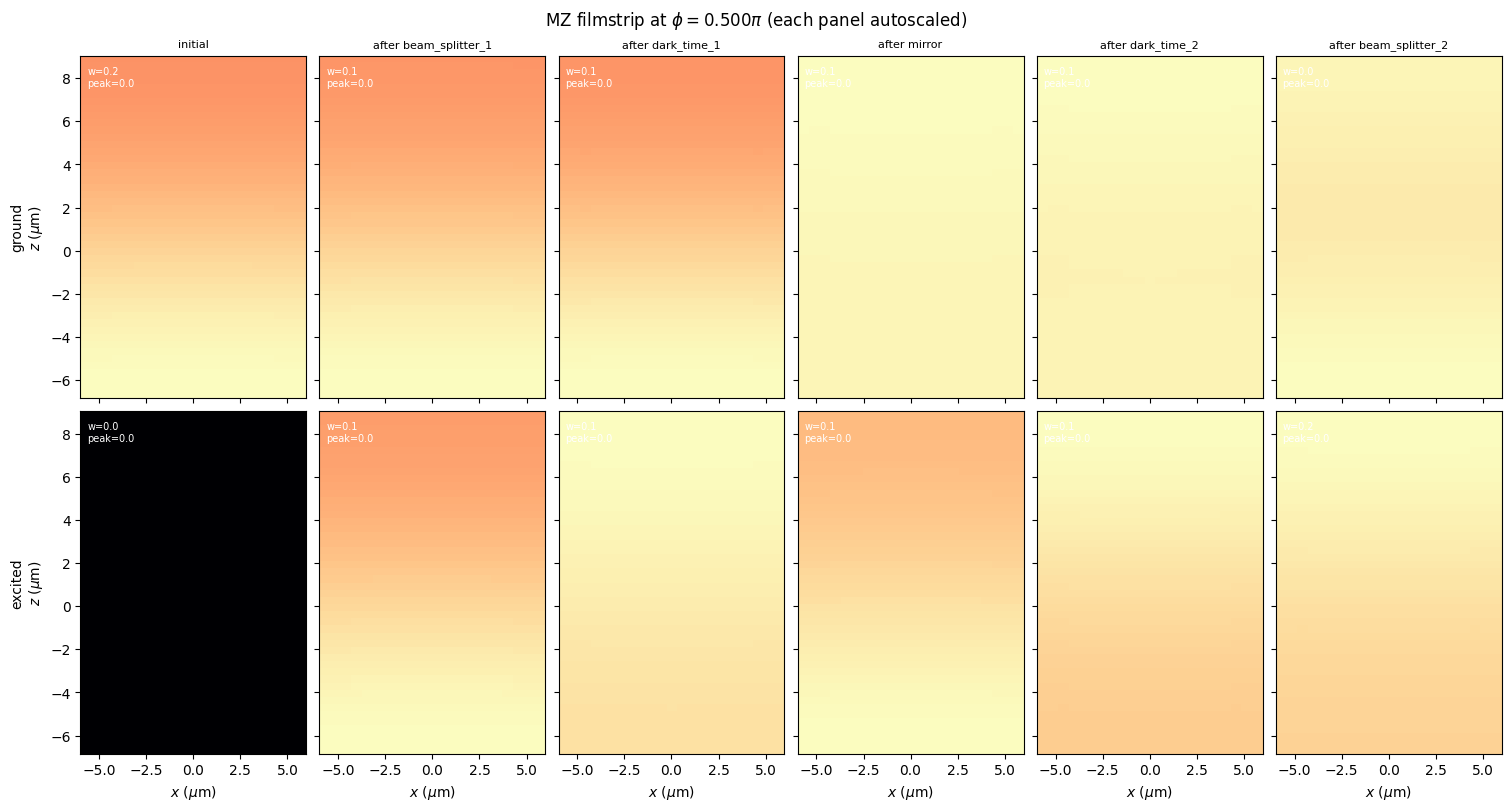

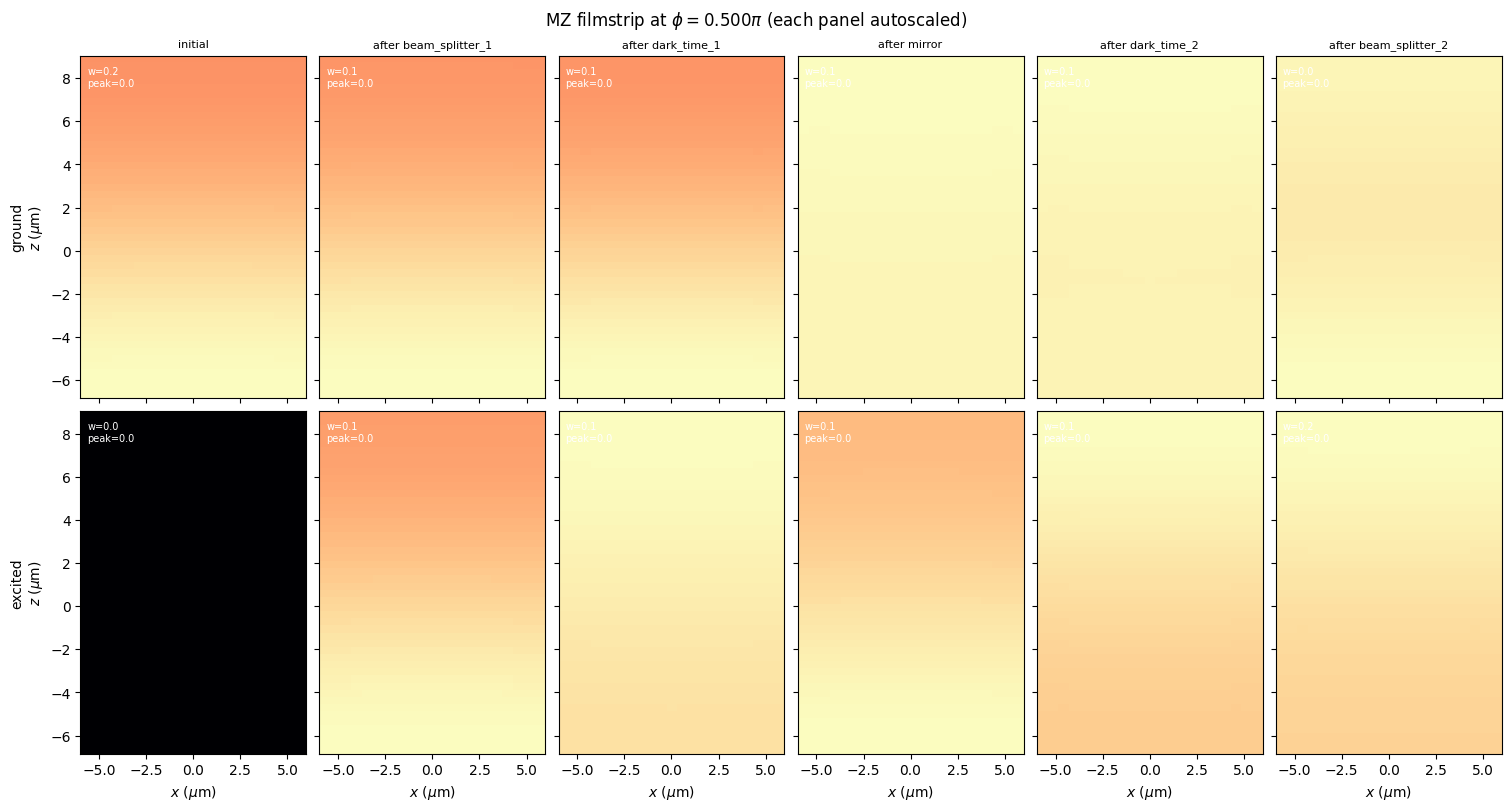

In [9]:
plot_mz_filmstrip(np.pi / 2)


phi=1.000pi:   0%|          | 0/200 [00:00<?, ?it/s]


phi=1.000pi:  38%|███▊      | 76/200 [00:00<00:00, 753.05it/s]


phi=1.000pi:  76%|███████▌  | 152/200 [00:00<00:00, 734.60it/s]


phi=1.000pi: 100%|██████████| 200/200 [00:00<00:00, 735.11it/s]

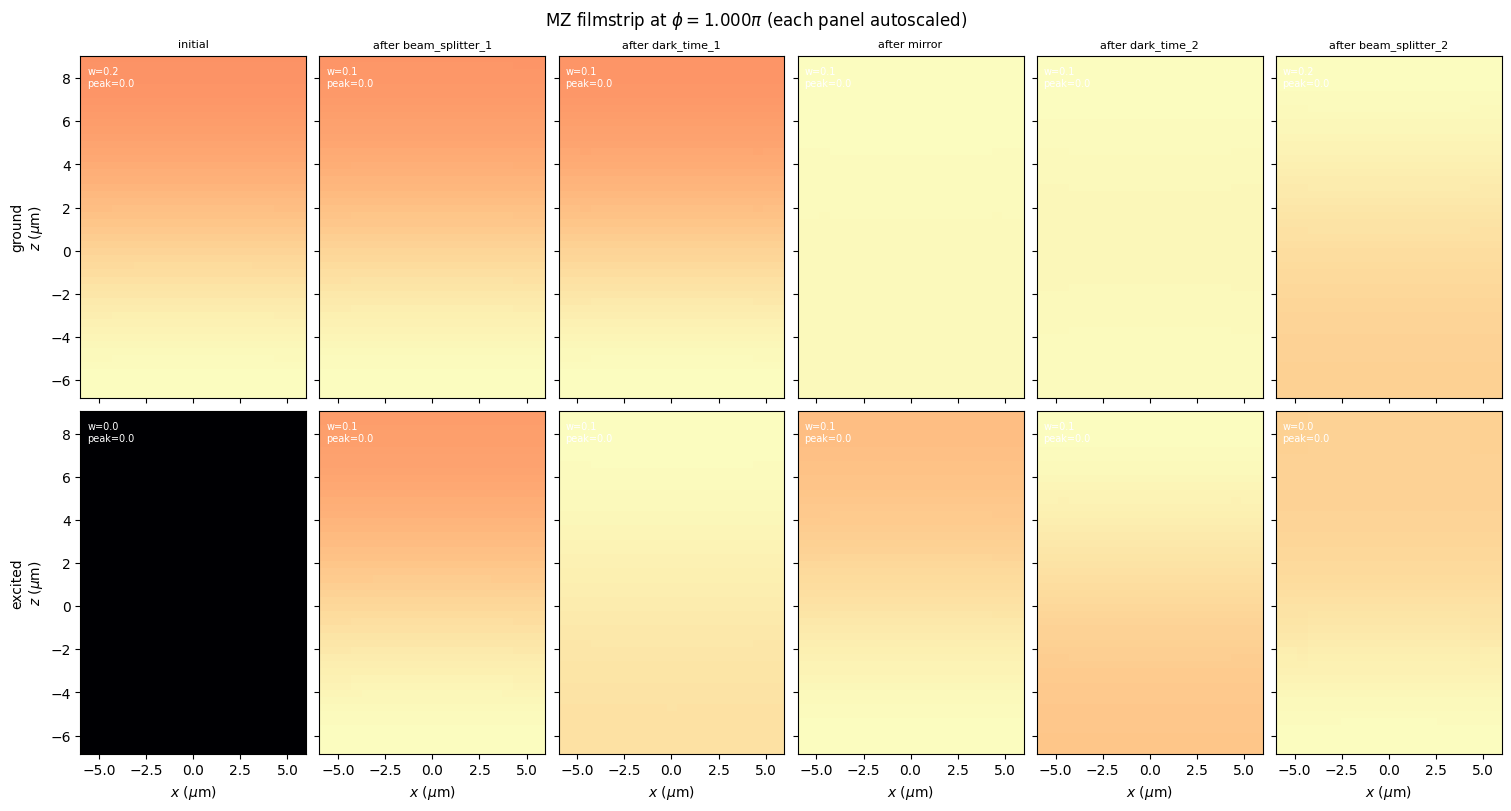

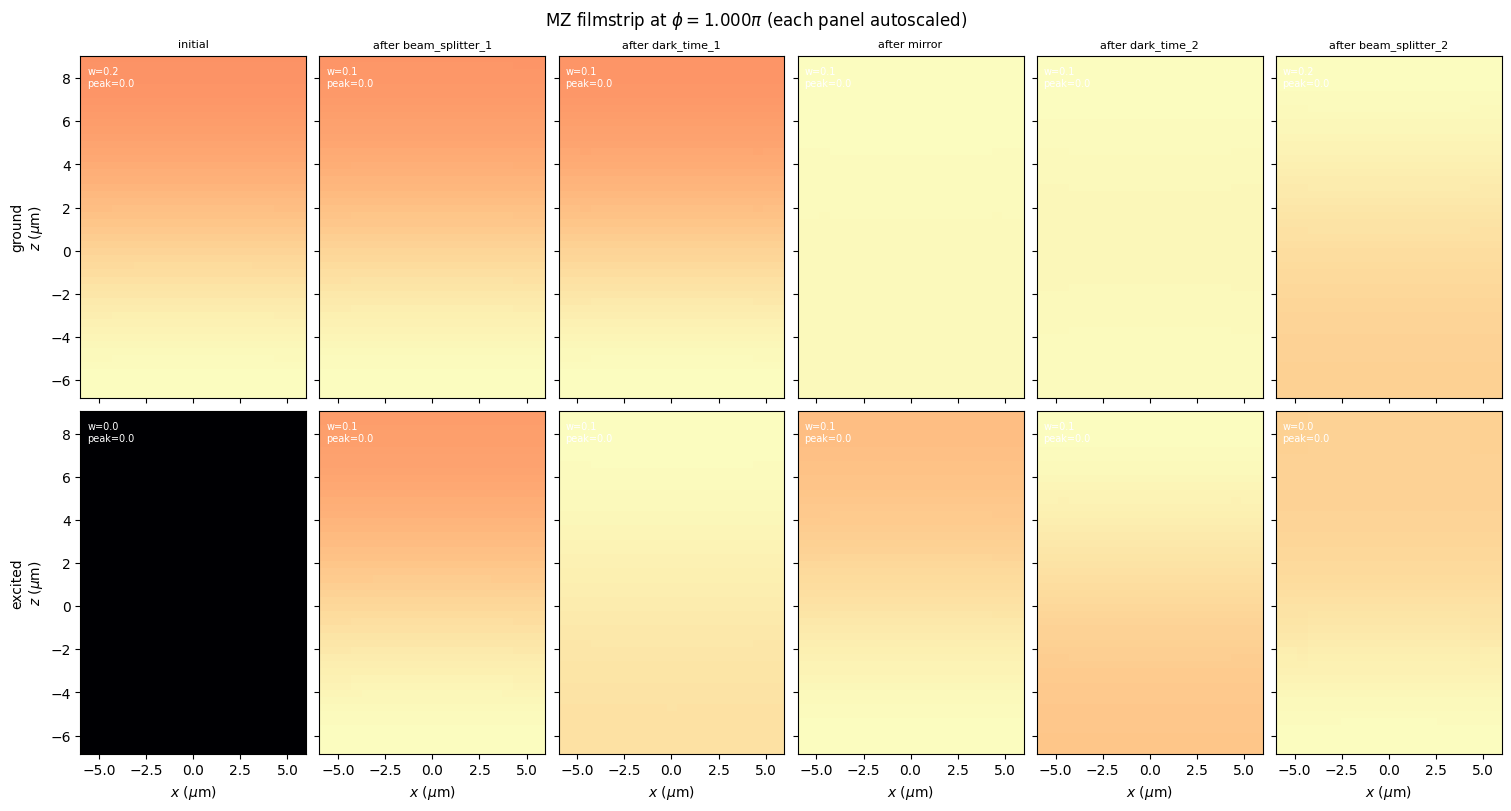

In [10]:
plot_mz_filmstrip(np.pi)


phi=1.500pi:   0%|          | 0/200 [00:00<?, ?it/s]


phi=1.500pi:  36%|███▋      | 73/200 [00:00<00:00, 721.89it/s]


phi=1.500pi:  73%|███████▎  | 146/200 [00:00<00:00, 725.56it/s]


phi=1.500pi: 100%|██████████| 200/200 [00:00<00:00, 725.61it/s]

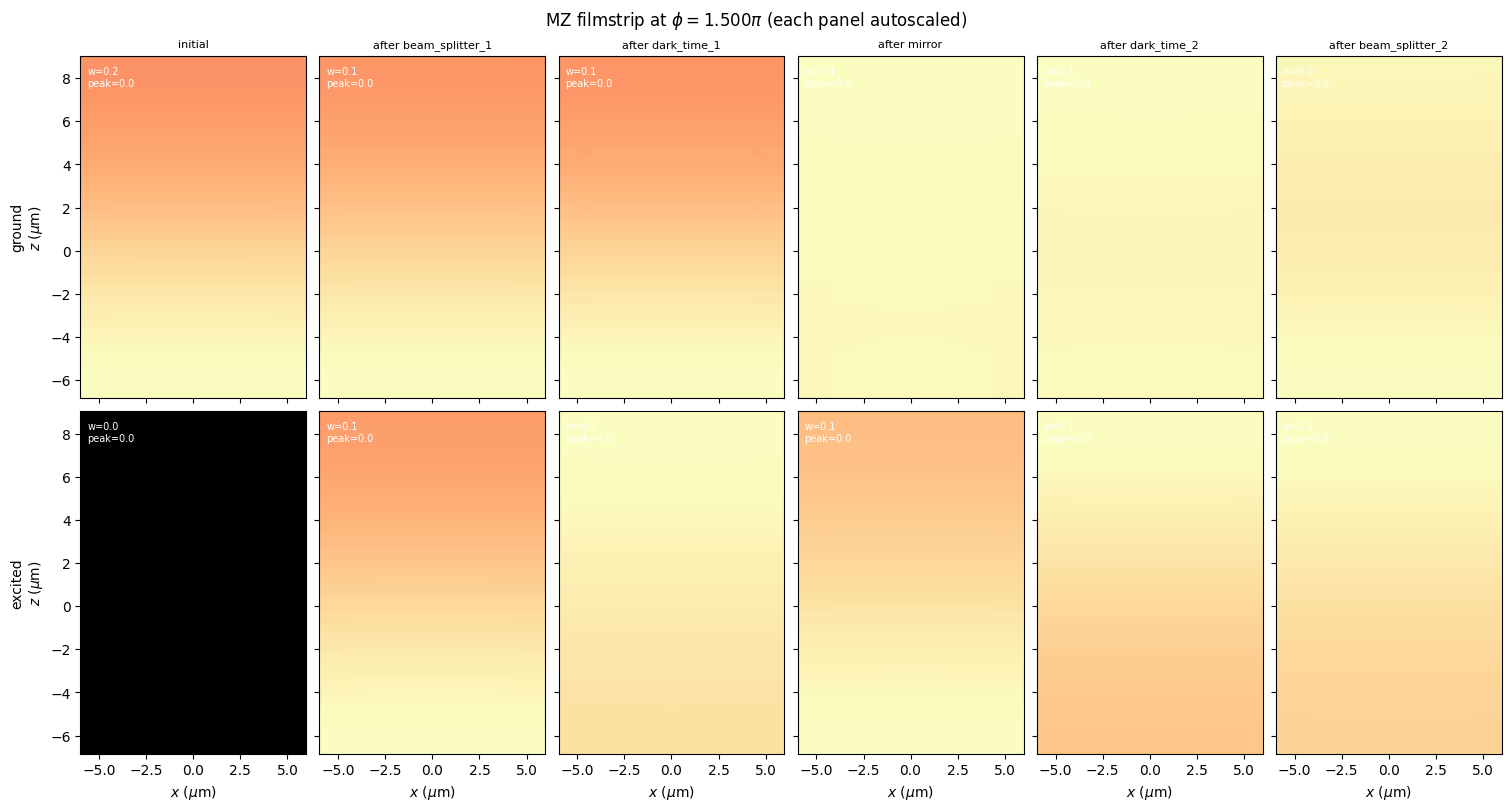

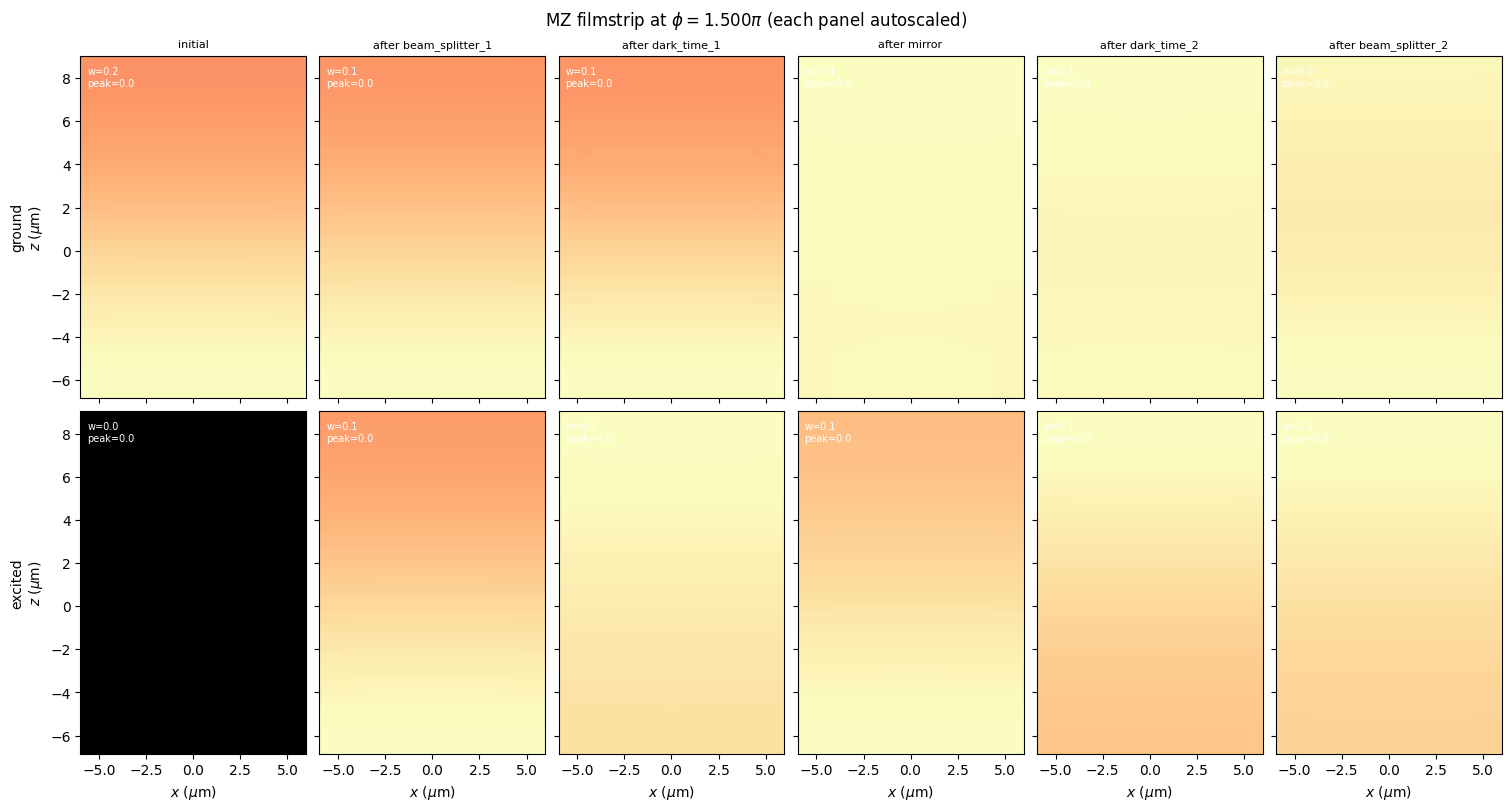

In [11]:
plot_mz_filmstrip(3 * np.pi / 2)


phi=2.000pi:   0%|          | 0/200 [00:00<?, ?it/s]


phi=2.000pi:  35%|███▌      | 70/200 [00:00<00:00, 696.82it/s]


phi=2.000pi:  71%|███████   | 142/200 [00:00<00:00, 708.38it/s]


phi=2.000pi: 100%|██████████| 200/200 [00:00<00:00, 708.43it/s]

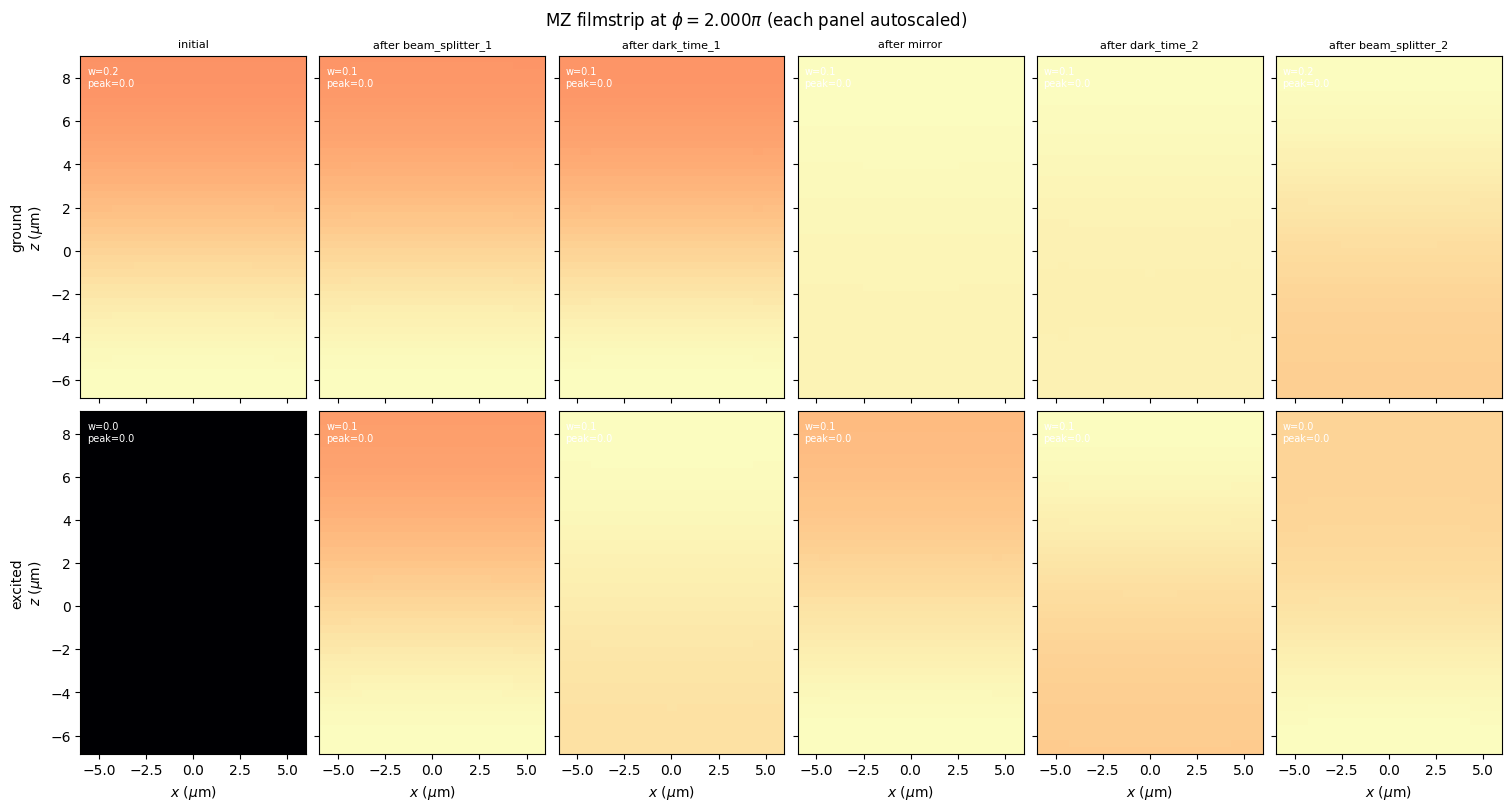

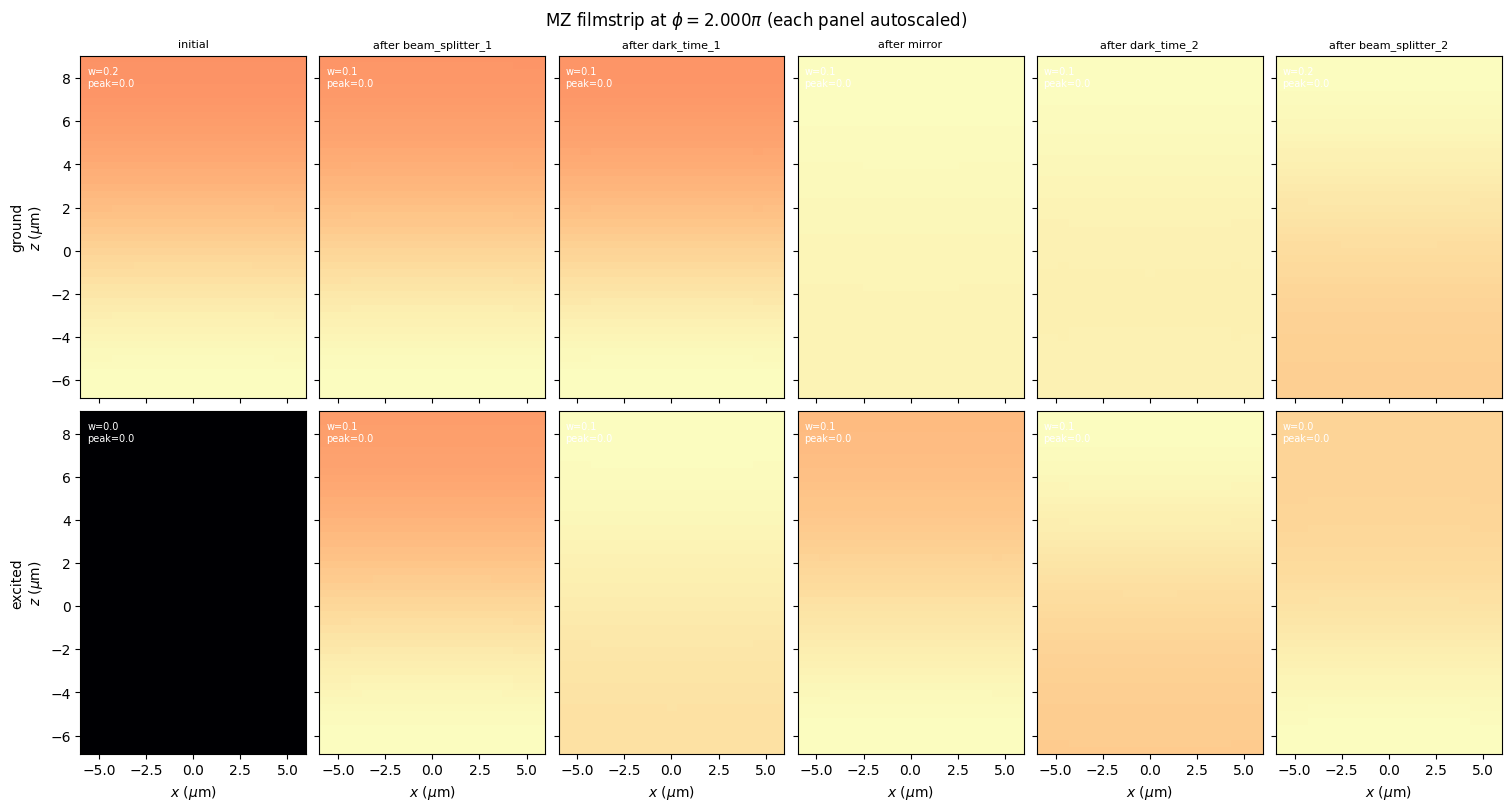

In [12]:
plot_mz_filmstrip(2 * np.pi)